In [1]:
import sys
from pathlib import Path
import camelot
import pandas as pd
print("✓ Import successful!")


✓ Import successful!


In [ ]:
from docling.document_converter import DocumentConverter

source = "pdfs/Analysis.pdf"  # file path or URL
converter = DocumentConverter()
doc = converter.convert(source)


In [ ]:
tables = camelot.read_pdf('pdfs/Analysis.pdf', pages = 'all', flavor='stream', edge_tol = 700)

In [ ]:
from pandas import DataFrame

def max_speed_transformation(ds) -> DataFrame:
    """ Function to transform the ds for the maximum speed pdf 
    """
    # rimuovere le righe vuote 
    ds = ds.dropna(axis = 0, how='all')
    # drop right non significative 
    ds = ds.drop([0,1,2])
    ds = ds.dropna(axis = 1, how='all')
    ds.reset_index(drop=True, inplace=True)
    # attirubure altre colonne che si interfaccino ai csv 
    frst_row = ds.iloc[0].to_list()
    frst_row = ['Rider_number' if val =='#' else val for val in frst_row]
    ds.columns = frst_row

    for col in ds.columns:
        if col == '':
            print('Empty column: dropping')
            ds.drop(columns=[col], inplace=True)
        else:
            pass
    # frop old first rows
    ds.drop(index=0, inplace=True)
    # formattare dove serve
    ds['Km/h'] = ds['Km/h'].astype(float)
    ds.columns = [col.lower().replace('/','_').replace(' ','_') for col in ds.columns]
    # reindicizzare 
    return ds 


## Alternative: Better approach using Camelot directly

Since the Docling markdown is messy, let's use Camelot to extract tables more cleanly:

In [2]:
tables = camelot.read_pdf('pdfs/Analysis.pdf', pages='all', flavor='stream', table_areas=['30,800,575,70'])


/var/folders/x7/95tncts51wg9pq9zsr2lrrfc0000gn/T/ipykernel_67023/1046424398.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  camelot.plot(tables[4], kind = 'contour').show()


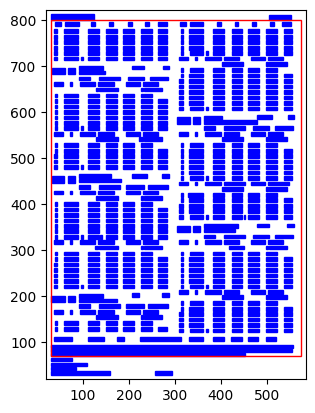

In [98]:
camelot.plot(tables[4], kind = 'contour').show()

In [ ]:
tables[0].df

In [125]:
# copy to preserve 
ds = tables[0].df.copy(deep = True)

In [126]:
while ds.iloc[0,0] != 'Lap':
    if ds.iloc[0,0] == 'Lap':
        break
    ds = ds.drop(axis = 0, index = 0).reset_index(drop= True)
print("Got to start table")


Got to start table


In [ ]:
# aöternative method
# Remove rows until the first column value is "Lap"
# while len(tables[0].df) > 0 and tables[0].df.iloc[0, 0] != 'Lap':
#     print(f"Dropping row with value: {tables[0].df.iloc[0, 0]}")
#     tables[0].df = tables[0].df.iloc[1:].reset_index(drop=True)

# print("Done! First column value is now:", tables[0].df.iloc[0, 0])

## add the same below to remove everything after faster lap or simpliy from the bottom until Fastest Lap:

In [127]:
## prima regola 
    ## se c'e´ una colonna vuota tra Lap time e T1 e´il nome del pilota
    ## se c'e´ una colonna vuota tra altre colonne, vanno attaccate alla coonna alla loro sinistra 

ds.columns = ds.iloc[0].to_list()
ds.drop(axis = 0, index = 0, inplace=True)

In [128]:
for i in range(len(ds.columns)):
    if ds.columns[i] == '' and ds.columns[i-1] == 'Lap Time' and ds.columns[i+1] == 'T1':
        print('Empty column between Lap time and T1: likely rider name column')
        ds.columns.values[i] = 'Rider Name'
    elif ds.columns[i] == '' and ds.columns[i-1] != 'Lap Time':
        print("Probably empty column to be merged")
        ds.columns.values[i] = 'merge'

Empty column between Lap time and T1: likely rider name column
Empty column between Lap time and T1: likely rider name column
Probably empty column to be merged


In [129]:
for idx, col in enumerate(ds.columns):
    if col == 'merge':
        ds.iloc[:,idx-1] = ds.iloc[:,idx-1] + ' ' + ds.iloc[:,idx]

ds.drop(axis = 1, columns = ['merge'], inplace= True)

## rimouovere ora il bottom con fastest lap 
## dopo dividere il df in due e concatenare le parti, e concat verticalmente 
## da qui devo trovare in modo per estrapolare le informazioni del pilota e dei giri 
## magari posso mettere un placeholder ripetuto da 
## ma non avendo duplicati sara piu semplice


In [130]:

# remove rows from last to up until Fastest Lap
i = -1
removed_rows = []
while ds.iloc[i,0] != 'Fastest Lap:':
    print(f"Checking row {i} with value {ds.iloc[i,0]} should be removed")
    if ds.iloc[i,0] == 'Fastest Lap:':
        i += -1
        break
    
    removed_rows.append(i)
    i += -1
    print(f"Row with value {ds.iloc[i,0]} should be removed")

print("Got to end bottom")

removed_index = ds.index[removed_rows]
ds.drop(axis = 0, index = removed_index, inplace = True)

Checking row -1 with value  should be removed
Row with value  should be removed
Checking row -2 with value  should be removed
Row with value  should be removed
Checking row -3 with value  should be removed
Row with value Fastest Lap: should be removed
Got to end bottom


In [131]:
cut_half = int(len(ds.columns) / 2)
ds_a = ds.iloc[:,0:cut_half]
ds_b = ds.iloc[:,cut_half:]
ds = pd.concat([ds_a, ds_b], axis = 0).reset_index(drop = True)
print(f"New shape of the dataframe is {ds.shape} while old one is {tables[0].df.shape}")

New shape of the dataframe is (162, 8) while old one is (94, 17)


In [132]:
lentgh = ds.shape[0]
dropping_index = []
for i in range(lentgh):
    if ds.iloc[i,0] == '':
        dropping_index.append(i)
        print(f"Row {i} is empty and should be removed")
        

Row 0 is empty and should be removed
Row 1 is empty and should be removed
Row 3 is empty and should be removed
Row 5 is empty and should be removed
Row 6 is empty and should be removed
Row 7 is empty and should be removed
Row 9 is empty and should be removed
Row 11 is empty and should be removed
Row 13 is empty and should be removed
Row 15 is empty and should be removed
Row 17 is empty and should be removed
Row 19 is empty and should be removed
Row 21 is empty and should be removed
Row 23 is empty and should be removed
Row 25 is empty and should be removed
Row 27 is empty and should be removed
Row 29 is empty and should be removed
Row 31 is empty and should be removed
Row 33 is empty and should be removed
Row 35 is empty and should be removed
Row 37 is empty and should be removed
Row 38 is empty and should be removed
Row 39 is empty and should be removed
Row 41 is empty and should be removed
Row 43 is empty and should be removed
Row 45 is empty and should be removed
Row 46 is empty and

In [133]:
ds.drop(axis = 0, index = dropping_index, inplace= True)
ds.reset_index(drop = True, inplace = True)

In [134]:
ds

,Lap,Lap Time,Rider Name,T1,T2,T3,T4,Speed
0,1st,79,Trackhouse MotoGP Team,,,,,
1,Run #,1,Front Tyre,,Slick-Soft,Rear Tyre,Slick-Soft,
2,1,1'52.360,,22.669,27.189,23.345,25.255,
3,2,1'33.694,,21.160,25.491,22.315,24.728,325.8
4,3,1'31.618,,20.437,24.911,21.801,24.469,327.4
...,...,...,...,...,...,...,...,...
63,5,1'30.318,,20.212,24.390,21.494,24.222,328.9
64,6,1'30.636,,20.342,24.399,21.576,24.319,327.4
65,7,1'41.971,P,22.395,26.835,22.720,30.021,324.3
66,Run #,2,Front Tyre,Slick-Soft,,Rear Tyre,Slick-Soft,


In [ ]:
# creare una colonna rider id
# colonna numero run 
# colonna rear type e colonna front tyre

ordinals = [f"{i}{'th' if 10<=i%100<=20 else {1:'st',2:'nd',3:'rd'}.get(i%10,'th')}" for i in range(1, 41)]
# find rider id based on the arrival order 
# take the second column for each of the values when encountered 

ds['order_grid'] = ds.iloc[:,0].apply(lambda x: x if x in ordinals else None)
ds['order_grid'] = ds['order_grid'].ffill()
# First assign the run numbers
ds.loc[ds['Lap'] == 'Run #', 'run_number'] = ds['Lap Time']

# Then forward fill to propagate to all rows
ds['run_number'] = ds['run_number'].ffill()
# extract as df the order of arrival

arrival_order = {}
arrival_team = {}

for i in range(ds.shape[0]):
    if ds.iloc[i,0] in ordinals:
        arrival_order[ds.iloc[i,0]] = ds.iloc[i,1]
        arrival_team[ds.iloc[i,0]] = ds.iloc[i,2]


ds['rider_id'] = ds['order_grid'].map(arrival_order)
ds['rider_team'] = ds['order_grid'].map(arrival_team)



In [140]:
ds

,Lap,Lap Time,Rider Name,T1,T2,T3,T4,Speed,order_grid,run_number,rider_id,rider_team
0,1st,79,Trackhouse MotoGP Team,,,,,,1st,NaN,79,Trackhouse MotoGP Team
1,Run #,1,Front Tyre,,Slick-Soft,Rear Tyre,Slick-Soft,,1st,1,79,Trackhouse MotoGP Team
2,1,1'52.360,,22.669,27.189,23.345,25.255,,1st,1,79,Trackhouse MotoGP Team
3,2,1'33.694,,21.160,25.491,22.315,24.728,325.8,1st,1,79,Trackhouse MotoGP Team
4,3,1'31.618,,20.437,24.911,21.801,24.469,327.4,1st,1,79,Trackhouse MotoGP Team
...,...,...,...,...,...,...,...,...,...,...,...,...
63,5,1'30.318,,20.212,24.390,21.494,24.222,328.9,4th,1,21,Pertamina Enduro VR46 Racing Team
64,6,1'30.636,,20.342,24.399,21.576,24.319,327.4,4th,1,21,Pertamina Enduro VR46 Racing Team
65,7,1'41.971,P,22.395,26.835,22.720,30.021,324.3,4th,1,21,Pertamina Enduro VR46 Racing Team
66,Run #,2,Front Tyre,Slick-Soft,,Rear Tyre,Slick-Soft,,4th,2,21,Pertamina Enduro VR46 Racing Team


In [ ]:
runs_data = []
for i in ds.index:
    # get the complete row when the first value is run #
    if ds.iloc[i,0] == 'Run #':
        
        runs_data.append(ds.iloc[i].to_dict())
runs_ds = pd.DataFrame(runs_data)
remove_columns = ['Lap','Lap Time','Speed', 'order_grid']
if runs_ds['Rider Name'].unique() == 'Front Tyre':
    remove_columns.append('Rider Name')

if runs_ds['T3'].unique() == 'Rear Tyre':
    remove_columns.append('T3')



runs_ds['front_tyre'] = runs_ds['T1'] + runs_ds['T2']
runs_ds.rename(columns={'T4': 'rear_tyre',}, inplace=True)
remove_columns.append('T1')
remove_columns.append('T2')

runs_ds.drop(axis = 1, columns = remove_columns, inplace= True)

,rear_tyre,run_number,rider_id,rider_team,front_tyre
0,Slick-Soft,1,79,Trackhouse MotoGP Team,Slick-Soft
1,Slick-Soft,2,79,Trackhouse MotoGP Team,Slick-Soft
2,Slick-Soft,1,63,Ducati Lenovo Team,Slick-Soft
3,Slick-Medium,2,63,Ducati Lenovo Team,Slick-Soft
4,Slick-Medium,1,72,Aprilia Racing,Slick-Soft
5,Slick-Soft,2,72,Aprilia Racing,Slick-Soft
6,Slick-Soft,1,21,Pertamina Enduro VR46 Racing Team,Slick-Soft
7,Slick-Soft,2,21,Pertamina Enduro VR46 Racing Team,Slick-Soft


In [ ]:
ds = pd.merge(ds, runs_ds[['run_number', 'rider_id', 'front_tyre', 'rear_tyre']], 
            left_on = ['run_number', 'rider_id'],
            right_on=['run_number', 'rider_id'], 
            how = 'left')

ds

,Lap,Lap Time,Rider Name,T1,T2,T3,T4,Speed,order_grid,run_number,rider_id,rider_team,front_tyre,rear_tyre
0,1st,79,Trackhouse MotoGP Team,,,,,,1st,NaN,79,Trackhouse MotoGP Team,NaN,NaN
1,Run #,1,Front Tyre,,Slick-Soft,Rear Tyre,Slick-Soft,,1st,1,79,Trackhouse MotoGP Team,Slick-Soft,Slick-Soft
2,1,1'52.360,,22.669,27.189,23.345,25.255,,1st,1,79,Trackhouse MotoGP Team,Slick-Soft,Slick-Soft
3,2,1'33.694,,21.160,25.491,22.315,24.728,325.8,1st,1,79,Trackhouse MotoGP Team,Slick-Soft,Slick-Soft
4,3,1'31.618,,20.437,24.911,21.801,24.469,327.4,1st,1,79,Trackhouse MotoGP Team,Slick-Soft,Slick-Soft
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,5,1'30.318,,20.212,24.390,21.494,24.222,328.9,4th,1,21,Pertamina Enduro VR46 Racing Team,Slick-Soft,Slick-Soft
64,6,1'30.636,,20.342,24.399,21.576,24.319,327.4,4th,1,21,Pertamina Enduro VR46 Racing Team,Slick-Soft,Slick-Soft
65,7,1'41.971,P,22.395,26.835,22.720,30.021,324.3,4th,1,21,Pertamina Enduro VR46 Racing Team,Slick-Soft,Slick-Soft
66,Run #,2,Front Tyre,Slick-Soft,,Rear Tyre,Slick-Soft,,4th,2,21,Pertamina Enduro VR46 Racing Team,Slick-Soft,Slick-Soft


In [164]:
delete_indexes = []
for i in ds.index: 
    if ds.iloc[i,0] == 'Run #':
        delete_indexes.append(i)
    elif ds.iloc[i,0] == 'Fastest Lap:':
        delete_indexes.append(i)
    elif ds.iloc[i,0] in ordinals:
        delete_indexes.append(i)

In [165]:
delete_indexes

[0, 1, 16, 20, 21, 30, 34, 38, 39, 52, 57, 58, 66]